# SCC0276 - Aprendizado de Máquina - EXERCÍCIO 6




# Investigação do efeito do kernel

Na primeira parte dos exercícios desta semana, iremos trabalhar novamente com dados sintéticos. Desta vez, iremos abordar um conjunto de dados que visívelmente **não é linearmente separável** para uma tarefa de classificação.

## Classificação usando dados sintéticos

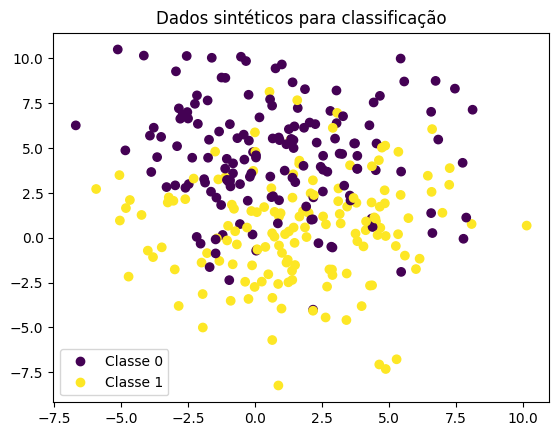

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np

X, y = make_blobs(n_samples=300, centers=2, cluster_std=3.0, random_state=0)
fig = plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dados sintéticos para classificação")

handles, _ = fig.legend_elements()
cluster_ids = np.unique(y)
labels = [f"Classe {i}" for i in cluster_ids]

plt.legend(handles, labels)
plt.show()

## Pre-processamento dos dados

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# iremos preparar um conjunto de validação e processá-lo usando padronização
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Função auxiliar para visualização

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_decision_boundary(estimator, X, y, title):
    '''Plota a fronteira de decisão do classificador
    Parameters:
    estimator: classificador treinado
    X: dados de entrada (2D). devem estar padronizados.
    y: rótulos das classes.
    title:   do gráfico
    '''
    display = DecisionBoundaryDisplay.from_estimator(estimator, X, response_method='predict', cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.show()

## 1) SVMs para classificação

Neste exercício, o intuito é verificar a influência do parâmetro que especifica o kernel usado para treinamento de uma SVM. Sendo assim, neste exercício siga os seguintes passos.

1. Avalie inicialmente uma [SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) usando o kernel 'linear'. Indique qual a principal implicação de usar este kernel. Configure a seed do modelo para o valor 2026 e extraia métricas de classificação como acurácia, precisão, revocação e medida F1.
2. Avalie mais duas SVMs, porém variando o valor do kernel ('rbf', 'sigmoid', etc). Dentre todas as SVMs avaliadas, indique qual a melhor para os dados sintéticos estudados.
3. Use a função auxiliar '*plot_decision_boundary*' para visualizar as bordas de decisão da SVM com kernel linear, e a SVM com os melhores resultados na etapa anterior. Utilize os pares X (padronizados) e y de teste como entradas. Comente o impacto da escolha do kernel com base nas visualizações.

LINEAR
Acurácia: 0.7833
Precisão: 0.7576
F1_Score: 0.7937
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.8333

SIGMOID
Acurácia: 0.6000
Precisão: 0.6071
F1_Score: 0.5862
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.5667

RBF
Acurácia: 0.8333
Precisão: 0.8125
F1_Score: 0.8387
Sensibilidade (Taxa de Verdadeiros Positivos - TVP): 0.8667



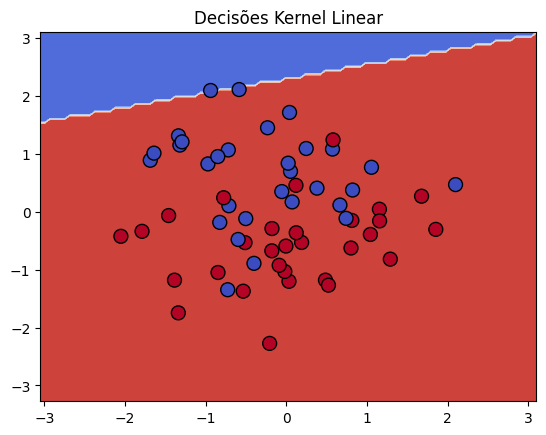

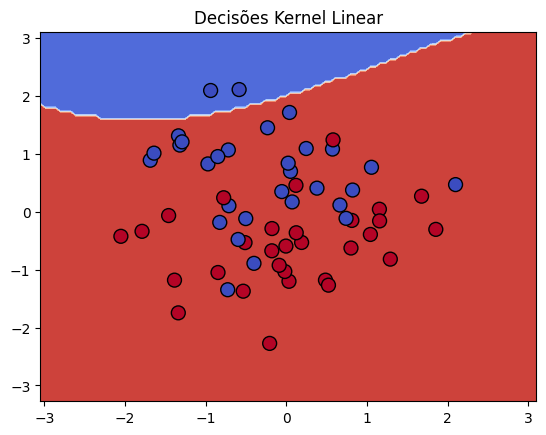

In [ ]:
from sklearn import svm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

# 1.
# Kernel Linear
clf_linear = svm.SVC(kernel = 'linear', random_state = 2026)
clf_linear.fit(X_train, y_train)

y_pred = clf_linear.predict(X_test)
y_pred

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("LINEAR")
print("Acurácia: %.4f" % acc)
print("Precisão: %.4f" % prec)
print("F1_Score: %.4f" % f1)
print("Sensibilidade (Taxa de Verdadeiros Positivos - TVP): %.4f\n" % rec)

# 2.
# Kernel Sigmoid
clf_sigmoid = svm.SVC(kernel = 'sigmoid', random_state = 2026)
clf_sigmoid.fit(X_train, y_train)

y_pred = clf_sigmoid.predict(X_test)
y_pred

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("SIGMOID")
print("Acurácia: %.4f" % acc)
print("Precisão: %.4f" % prec)
print("F1_Score: %.4f" % f1)
print("Sensibilidade (Taxa de Verdadeiros Positivos - TVP): %.4f\n" % rec)

# Kernel Radial Basis Function
clf_rbf = svm.SVC(kernel = 'rbf', random_state = 2026)
clf_rbf.fit(X_train, y_train)

y_pred = clf_rbf.predict(X_test)
y_pred

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("RBF")
print("Acurácia: %.4f" % acc)
print("Precisão: %.4f" % prec)
print("F1_Score: %.4f" % f1)
print("Sensibilidade (Taxa de Verdadeiros Positivos - TVP): %.4f\n" % rec)

# A SVM com melhores resultados das métricas de avalição foi a RBF para os dados sintéticos estudados.

# 3.

plot_decision_boundary(clf_linear, X_test_scaled, y_test, "Decisões Kernel Linear")
plot_decision_boundary(clf_rbf, X_test_scaled, y_test, "Decisões Kernel Linear")

## Regressão utilizando dados reais

Considere o arquivo `houses_to_rent_v2.csv`. Esta base tem dados de imóveis para 5 cidades do Brasil. Esta base pode ser usada tanto pelo proprietário quanto pelo locatário. Pretende-se que um proprietario
tenha uma estimativa do preço que pode alugar seu imóvel, através de seus atributos. Por outro lado, pretende-se que um locatário possa estimar se o aluguel é condizente.

Nesta segunda parte do exercício, a tarefa alvo será **regressão**. O diferencial desta base de dados é a presença simultânea de dados numéricos e categóricos. Além disto, usaremos o método SVM para a tarefa, usando o [SVR]((https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)) implementado pelo sklearn.

### Carregando o arquivo

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving houses_to_rent_v2.csv to houses_to_rent_v2 (1).csv


In [ ]:
import pandas as pd

In [ ]:
DATA_PATH = "houses_to_rent_v2.csv"

In [ ]:
df = pd.read_csv(DATA_PATH)
df.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
0,São Paulo,70,2,1,1,7,acept,furnished,2065,3300,211,42,5618
1,São Paulo,320,4,4,0,20,acept,not furnished,1200,4960,1750,63,7973
2,Porto Alegre,80,1,1,1,6,acept,not furnished,1000,2800,0,41,3841
3,Porto Alegre,51,2,1,0,2,acept,not furnished,270,1112,22,17,1421
4,São Paulo,25,1,1,0,1,not acept,not furnished,0,800,25,11,836


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   city                 10692 non-null  object
 1   area                 10692 non-null  int64 
 2   rooms                10692 non-null  int64 
 3   bathroom             10692 non-null  int64 
 4   parking spaces       10692 non-null  int64 
 5   floor                10692 non-null  object
 6   animal               10692 non-null  object
 7   furniture            10692 non-null  object
 8   hoa (R$)             10692 non-null  int64 
 9   rent amount (R$)     10692 non-null  int64 
 10  property tax (R$)    10692 non-null  int64 
 11  fire insurance (R$)  10692 non-null  int64 
 12  total (R$)           10692 non-null  int64 
dtypes: int64(9), object(4)
memory usage: 1.1+ MB


In [ ]:
attr_df = df.drop(columns="rent amount (R$)")

In [ ]:
# separação simples de dados numéricos e categóricos
features_numericas = attr_df.select_dtypes(exclude=['object']).columns
features_categoricas = attr_df.select_dtypes(include=['object']).columns
print("Features numéricas:", features_numericas)
print("Features categóricas:", features_categoricas)

Features numéricas: Index(['area', 'rooms', 'bathroom', 'parking spaces', 'hoa (R$)',
       'property tax (R$)', 'fire insurance (R$)', 'total (R$)'],
      dtype='object')
Features categóricas: Index(['city', 'floor', 'animal', 'furniture'], dtype='object')


### Separação de treino e teste

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(attr_df, df["rent amount (R$)"], test_size=0.2, random_state=2026)

### Definindo pré-processamento específico para cada tipo de dado

Como mencionado anteriormente, esta base de dados possui dados numéricos e categóricos que deverão ser tratados de forma diferente. Para isto, iremos utilizar uma nova funcionalidade do sklearn: [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

Em resumo, esta classe é capaz de especificar uma sequência de operações para um conjunto de atributos. Ou seja, a ideia é especificar uma sequência de processamentos para dados numéricos e outra para dados categóricos.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
# definindo processamento de cada coluna. Note que o pipeline pode incluir mais de um passo, como por exemplo, tratamento de valores ausentes, etc.
# bastaria incluir mais algum pre-processamento na lista de steps
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', num_transformer, features_numericas),
        ('categoric', cat_transformer, features_categoricas)
])

In [ ]:
# aplicando o pré-processamento
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## 2) SVMs para regressão

Neste exercício, temos dois objetivos. Aplicar uma [SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) para regressão e investigar o efeito dos seus parâmetros na tarefa. Para estes objetivos:
1. Crie e avalie três SVRs, variando o kernel utilizado e utilizando 'C=100'.
2. Reporte 2 métricas de regressão a sua escolha.
3. Aponte o melhor modelo.


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Linear
SVR_linear = SVR(kernel = 'linear', C = 100)
SVR_linear.fit(X_train_processed, y_train)

y_pred = SVR_linear.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("LINEAR")
print("MAE: %.4f" % mae)
print("MSE: %.4f\n" % mse)

# Sigmoid
SVR_sigmoid = SVR(kernel = 'sigmoid', C = 100)
SVR_sigmoid.fit(X_train_processed, y_train)

y_pred = SVR_sigmoid.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("SIGMOID")
print("MAE: %.4f" % mae)
print("MSE: %.4f\n" % mse)

# Radial Basis Function
SVR_rbf = SVR(kernel = 'rbf', C = 100)
SVR_rbf.fit(X_train_processed, y_train)

y_pred = SVR_rbf.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("RBF")
print("MAE: %.4f" % mae)
print("MSE: %.4f\n" % mse)

LINEAR
MAE: 132.9186
MSE: 140976.7128

SIGMOID
MAE: 4563.4567
MSE: 104293155.4851

RBF
MAE: 186.7549
MSE: 938913.9574



## 3) Comparando SVMs com outros modelos

Usando o melhor modelo dos dois exercícios anteriores (com a melhor métrica de regressão), compare SVMs com dois outros modelos de regressão baseados em técnicas já vistas ao longo da disciplina (árvores de decisão, KNN, ensembles, MLPs, etc). Use as seguintes orientações.
1. Use os mesmos dados de treino e teste.
2. Ao criar os modelos, use a *seed* 2026 quando possível.
3. Customize os modelos escolhidos (parâmetros) ao seu critério.
4. Aponte o melhor modelo para a tarefa considerando métricas de regressão.


## Questões teóricas para estudo

Não é necessário responder as perguntas a seguir para completar a atividade prática. Utilize as perguntas para estudo posteriormente.

1. Explique o objetivo de uma *Support Vector Machine* em problemas de classificação. Como ele é alterado para problemas de regressão?
2. O que são vetores de suporte?
3. O que é a margem em SVM? Por que ela é importante?
4. Qual o papel do parâmetro C? O que acontece quando seu valor é muito alto? E quando é muito baixo?
5. No contexto de classificação, por que SVM linear não funciona bem em problemas não linearmente separáveis?
6. O que é o truque do kernel (kernel trick)?
7. O que significa projetar dados em um espaço de maior dimensão?

1. O objetivo de uma Support Vector Machine (SVM) em classificação é encontrar o hiperplano que melhor separa as classes, maximizando a margem entre elas. Em problemas de regressão (SVR – Support Vector Regression), o objetivo muda para encontrar uma função que aproxime os dados, permitindo um erro controlado dentro de uma margem de tolerância (ϵ).

2. Vetores de suporte são os exemplos de treinamento mais próximos da fronteira de decisão (hiperplano). Eles são os pontos que realmente influenciam a posição do hiperplano, sendo fundamentais para definir a separação entre as classes.

3. A margem em SVM é a distância entre o hiperplano de separação e os vetores de suporte mais próximos. Ela é importante porque margens maiores tendem a melhorar a capacidade de generalização, reduzindo o risco de overfitting.

4. O parâmetro C controla o equilíbrio entre maximizar a margem e minimizar erros de classificação. Quando C é muito alto, o modelo penaliza fortemente erros, podendo gerar overfitting. Quando C é muito baixo, o modelo aceita mais erros para manter uma margem maior, podendo causar underfitting.

5. A SVM linear não funciona bem em problemas não linearmente separáveis porque ela busca apenas uma fronteira linear de separação. Se os dados possuem relações complexas ou padrões não lineares, um hiperplano linear não consegue separar adequadamente as classes.

6. O truque do kernel (kernel trick) é uma técnica que permite calcular similaridades como se os dados tivessem sido projetados para um espaço de maior dimensão, sem realizar explicitamente essa transformação, reduzindo o custo computacional.

7. Projetar dados em um espaço de maior dimensão significa transformar os atributos originais em novas representações com mais dimensões, tornando possível separar dados que não eram linearmente separáveis no espaço original. Dessa forma, padrões complexos podem se tornar linearmente separáveis após a transformação.